# MNIST Lab

## MNIST reference:

- http://yann.lecun.com/exdb/mnist/
- https://www.kaggle.com/datasets/oddrationale/mnist-in-csv/data

## PyTorch reference:

- https://pytorch.org/docs/stable/index.html

## Data Preparation

In [16]:
# read the csv file (i.e., ./data/mnist.csv) with pandas
# store data into numpy arrays

import numpy as np
import pandas as pd

%time data = list(pd.read_csv("data/mnist_train.csv", header=None).values)
data = np.array(data)
# The image matrix
img = data[:, 1:].reshape((-1, 28, 28)) 
# The label list
lab = data[:, 0]
# The one-hot decoding label matrix
one = np.zeros((len(lab), 10))
one[range(len(lab)), lab] = 1
data = None

batch_size, learning_rate, epochs = 200, 0.1, 20

CPU times: user 1.46 s, sys: 293 ms, total: 1.75 s
Wall time: 1.65 s


In [17]:
# check loaded data by showing some key properties of the numpy arrays

print(img.shape, lab.shape, np.mean(one, axis=0))

(60000, 28, 28) (60000,) [0.09871667 0.11236667 0.0993     0.10218333 0.09736667 0.09035
 0.09863333 0.10441667 0.09751667 0.09915   ]


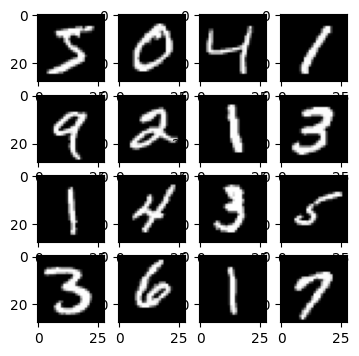

In [18]:
# check loaded data by showing a few images

import matplotlib.pyplot as plt
%matplotlib inline

size = 4
plt.figure(figsize=(size, size))
for i in range(size*size):
  plt.subplot(size, size, i+1)
  plt.imshow(img[i], cmap='gray')

In [19]:
# check loaded data by showing a few labels

print(lab[:size*size])
print(one[:size*size])

[5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7]
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]


In [20]:
# split the dataset into training and validation datasets
from sklearn.model_selection import train_test_split

img = img / 256

img_train, img_test, lab_train, lab_test, one_train, one_test = train_test_split(img, lab, one, test_size=0.2, random_state=2020)
print(img_train.shape, img_test.shape)
print(lab_train.shape, lab_test.shape)
print(one_train.shape, one_test.shape)

(48000, 28, 28) (12000, 28, 28)
(48000,) (12000,)
(48000, 10) (12000, 10)


## Pytorch Implementation

In [21]:
# set random seeds
import os
import random
import torch as pt

def set_seed(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    pt.manual_seed(seed)
    pt.cuda.manual_seed(seed)
    pt.cuda.manual_seed_all(seed)
    pt.backends.cudnn.benchmark = False
    pt.backends.cudnn.deterministic = True

In [22]:
import torch as pt
from tqdm.notebook import tqdm
from torch import nn, optim
from torch.autograd import Variable
from torch.utils.data import TensorDataset, DataLoader

set_seed(2025)
# define a simple neural network model
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.dense = nn.Sequential(nn.Flatten(),
                                   nn.Linear(28 * 28, 256), nn.ReLU(),
                                   nn.Linear(256, 256), nn.ReLU(),
                                   nn.Linear(256, 10))

    def forward(self, x):
        return self.dense(x)

# prepare the datasets for training
img_train = pt.from_numpy(img_train).float()
lab_train = pt.from_numpy(lab_train).long()
data_train = DataLoader(TensorDataset(img_train, lab_train), batch_size=batch_size, shuffle=True, drop_last=True)

img_test = pt.from_numpy(img_test).float()
lab_test = pt.from_numpy(lab_test).long()
data_test = DataLoader(TensorDataset(img_test, lab_test), batch_size=batch_size, shuffle=False, drop_last=True)

# train a simple neural network model
dev = pt.device('cuda')
model = MyModel().to(dev)
loss = nn.CrossEntropyLoss()
opt = optim.SGD(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    running_loss = []
    for x, y in data_train:
        x = Variable(x).to(dev)
        y = Variable(y).to(dev)
        model.train()
        yy = model(x)

        l = loss(yy, y)
        opt.zero_grad()
        l.backward()
        opt.step()
        running_loss.append(float(l))

    running_acc = []
    for x, y in data_test:
        x = Variable(x).to(dev)
        y = Variable(y).to(dev)
        model.eval()
        yy = model(x)
        yy = pt.argmax(yy, dim=1)

        acc = float(pt.sum(yy == y)) / batch_size
        running_acc.append(acc)

    print("#summary:% 4d %.4f %.2f%%" % (epoch, np.mean(running_loss), np.mean(running_acc)*100))

#summary:   0 0.9384 87.59%
#summary:   1 0.3425 90.63%
#summary:   2 0.2773 91.75%
#summary:   3 0.2351 92.99%
#summary:   4 0.2010 94.03%
#summary:   5 0.1747 94.76%
#summary:   6 0.1537 95.15%
#summary:   7 0.1364 95.31%
#summary:   8 0.1230 95.78%
#summary:   9 0.1098 96.33%
#summary:  10 0.1002 96.43%
#summary:  11 0.0914 96.72%
#summary:  12 0.0838 96.69%
#summary:  13 0.0767 96.76%
#summary:  14 0.0704 97.00%
#summary:  15 0.0649 97.28%
#summary:  16 0.0593 97.23%
#summary:  17 0.0551 97.35%
#summary:  18 0.0507 97.42%
#summary:  19 0.0470 97.23%


## Task
+ Rewrite the following cells to train and to evaluate the same neural network without using any Deep Learning APIs. That means you can only use NumPy or Tensors, but you cannot use torch.nn or torch.optim.
+ You can fill in the TODO part of the code below, or just delete it and write your own code from scratch

In [32]:
from copy import deepcopy as dco

class Neural_Network:
    def __init__(self, dims, data_train, data_test, epoch, batch_size, l_rate):
        # initialization
        # variable definitions: x_2 = ReLU(z_2), z_2 = x_1w_1 + b_1
        set_seed(2025)
        self.w, self.b, self.x = [], [], []
        self.x.append(np.zeros([batch_size, dims[0]], 'float64'))
        for i in range(1, len(dims)):
            self.w.append(np.random.uniform(-0.1, 0.1, (dims[i-1], dims[i])))
            self.b.append(np.zeros(dims[i], 'float64'))
            self.x.append(np.zeros((batch_size, dims[i]), 'float64'))
        
        # define the parameters
        self.layer_num = len(dims) - 1
        self.data_train = data_train
        self.data_test = data_test
        self.epoch = epoch
        self.batch_size = batch_size
        self.l_rate = l_rate
        self.z = dco(self.x)
        self.grad_x, self.grad_w, self.grad_b = dco(self.x), dco(self.w), dco(self.b)
    
    # define the activation function
    def actFunciton(self, x):
        return np.maximum(x, 0)
    
    # define the derivative of the activation function
    def actDerivation(self, x):
        # TODO: return the the derivative
        return (x > 0).astype(float)
    
    def softmax(self, x):
        x_exp = np.exp(x)
        x_exp_sum = np.sum(x_exp, axis=1, keepdims=True)
        return x_exp / x_exp_sum

    # define the forward function
    def forward(self):
        # update rule: x_2 = ReLU(z_2), z_2 = x_1w_1 + b_1
        # TODO: forward update z, x
        for i in range(2):
            self.z[i + 1] = np.dot(self.x[i], self.w[i]) + self.b[i]
            self.x[i + 1] = self.actFunciton(self.z[i + 1])
        
        self.x[3] = np.dot(self.x[2], self.w[2]) + self.b[2]

    # define the loss function
    def loss(self, y_pred, y_real):
        # TODO: return the cross entropy loss
        y_real_onehot = np.eye(y_pred.shape[1])[y_real]
        return - np.sum(np.log(np.sum(np.exp(y_pred * y_real_onehot) / np.sum(np.exp(y_pred), axis=1, keepdims=True), axis=1))) / self.batch_size
    
    # define the backward function
    def backward(self, y_real):
        # TODO: backward update grad_x, grad_w, grad_b
        self.grad_x[3] = self.softmax(self.x[3])
        self.grad_x[3][np.arange(self.batch_size), y_real] -= 1
        self.grad_x[3] /= self.batch_size
        
        self.grad_w[2] = np.dot(self.x[2].T, self.grad_x[3])
        self.grad_b[2] = np.sum(self.grad_x[3], axis=0)
        self.grad_x[2] = np.dot(self.grad_x[3], self.w[2].T)
    
    
        self.grad_w[1] = np.dot(self.x[1].T, self.grad_x[2] * self.actDerivation(self.x[2]))
        self.grad_b[1] = np.sum(self.grad_x[2] * self.actDerivation(self.x[2]), axis=0)
        self.grad_x[1] = np.dot(self.grad_x[2] * self.actDerivation(self.x[2]), self.w[1].T)
        
        self.grad_w[0] = np.dot(self.x[0].T, self.grad_x[1] * self.actDerivation(self.x[1]))
        self.grad_b[0] = np.sum(self.grad_x[1] * self.actDerivation(self.x[1]), axis=0)
        
        

    # define the update function
    def update(self):
        self.b = [self.b[i] - self.l_rate * self.grad_b[i] for i in range(self.layer_num)]
        self.w = [self.w[i] - self.l_rate * self.grad_w[i] for i in range(self.layer_num)]
    
    # train the neural network model
    def train(self):
        running_loss = []
        running_acc = []

        for epoch in range(self.epoch):
            for train_x, train_y in data_train:
                train_x = train_x.numpy()
                train_y = train_y.numpy()
                self.x[0] = train_x.reshape((self.batch_size, -1))
                self.forward()
                batch_loss = self.loss(self.x[-1], train_y)
                self.backward(train_y)
                self.update()
                running_loss.append(batch_loss)

            for test_x, test_y in data_test:
                test_x = test_x.numpy()
                test_y = test_y.numpy()
                self.x[0] = test_x.reshape((self.batch_size, -1))
                self.forward()
                out = np.argmax(self.x[-1], axis=1)
                running_acc.append(np.mean(out == test_y))

            print("#summary:% 4d %.4f %.2f%%" % (epoch, np.mean(running_loss), np.mean(running_acc) * 100))

# train the network
NN = Neural_Network([28 * 28, 256, 256, 10], data_train, data_test, epochs, batch_size, learning_rate)
NN.train()

#summary:   0 0.2084 89.66%
#summary:   1 0.2076 90.73%
#summary:   2 0.1951 91.67%
#summary:   3 0.1827 92.31%
#summary:   4 0.1716 92.88%
#summary:   5 0.1618 93.33%
#summary:   6 0.1531 93.71%
#summary:   7 0.1453 94.00%
#summary:   8 0.1384 94.27%
#summary:   9 0.1321 94.51%
#summary:  10 0.1263 94.70%
#summary:  11 0.1211 94.89%
#summary:  12 0.1163 95.06%
#summary:  13 0.1119 95.19%
#summary:  14 0.1078 95.32%
#summary:  15 0.1039 95.44%
#summary:  16 0.1004 95.56%
#summary:  17 0.0970 95.67%
#summary:  18 0.0939 95.75%
#summary:  19 0.0909 95.84%
